In [ ]:
Milestone — Location Verification & File Status (Week 2, Day 1)
Purpose: This turns on our "GPS diagnostic flashlight." It checks that Python is looking at the correct Windows folders and verifies that all 5 of your primary financial tables are successfully found.

In [11]:
# ==============================================================================
# MILESTONE: Week 2, Day 1 (Part A) - Environment Link & Verification
# Description: Establishes a raw-string path connection to the absolute dataset 
#              directory and checks file availability.
# ==============================================================================

import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Explicitly pin your exact Windows folder locations using raw strings
PROJECT_ROOT = r"C:\Users\HP\nifty100-intelligence"
DATASETS_DIR = r"C:\Users\HP\nifty100-intelligence\supporting datasets"

print("--- 🗺️ GPS Location Check ---")
print("Targeting Main Project at:", PROJECT_ROOT)
print("Targeting Excel Files at:", DATASETS_DIR)

if os.path.exists(DATASETS_DIR):
    print("\n📁 Connected to 'supporting datasets' folder successfully!")
    print("Files found inside:", os.listdir(DATASETS_DIR))
else:
    print("\n❌ Path Error: Python cannot find the folder. Check spelling!")

--- 🗺️ GPS Location Check ---
Targeting Main Project at: C:\Users\HP\nifty100-intelligence
Targeting Excel Files at: C:\Users\HP\nifty100-intelligence\supporting datasets

📁 Connected to 'supporting datasets' folder successfully!
Files found inside: ['financial_ratios.xlsx', 'market_cap.xlsx', 'peer_groups.xlsx', 'sectors.xlsx', 'stock_prices.xlsx']


In [ ]:
 Milestone — The Missing Data Hunt (Week 2, Day 1)
Purpose: This runs the data audit. It counts the empty blanks in your columns and draws the purple-and-yellow Data Quality Map to visually highlight where information is missing (like missing interest coverages).

🎉 SUCCESS! Data loaded without errors.
Total dataset rows available: 1184

--- 🔍 Data Quality Check (Missing Values per Column) ---
id                              0
company_id                      0
year                            0
net_profit_margin_pct           1
operating_profit_margin_pct    61
return_on_equity_pct            0
debt_to_equity                  0
interest_coverage              93
asset_turnover                  1
free_cash_flow_cr               2
capex_cr                        2
earnings_per_share              4
book_value_per_share            0
dividend_payout_ratio_pct       4
total_debt_cr                   0
cash_from_operations_cr         2
dtype: int64


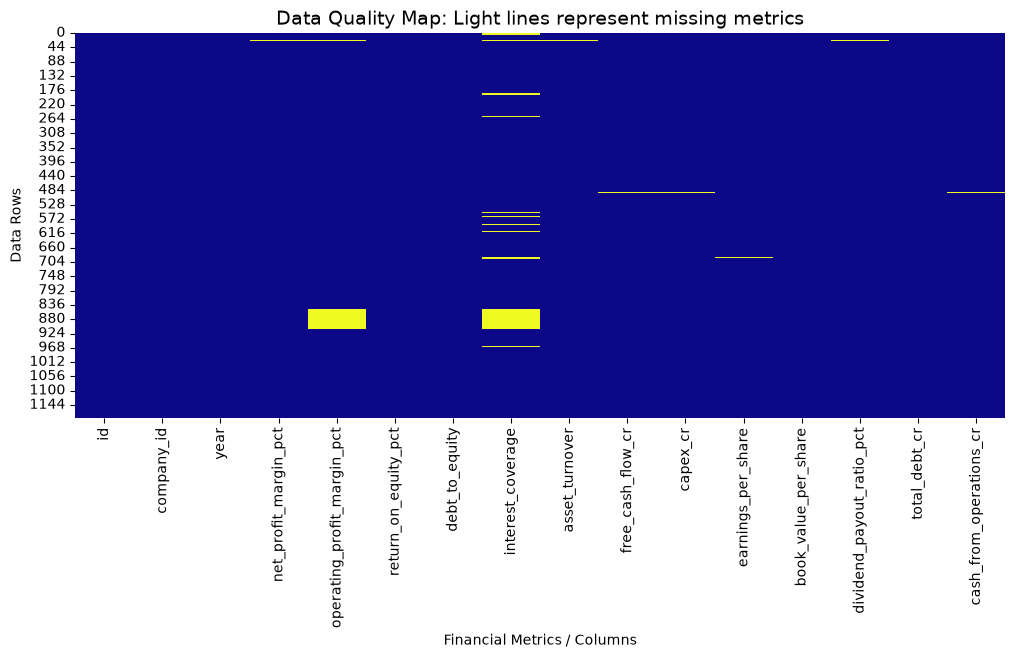

In [12]:
# ==============================================================================
# MILESTONE: Week 2, Day 1 (Part B) - Data Quality Scan & Missing Gaps Heatmap
# Description: Audits individual columns for missing records and produces 
#              a visual matrix of dataset completeness.
# ==============================================================================

# Load your core financial spreadsheet
ratios_df = pd.read_excel(os.path.join(DATASETS_DIR, "financial_ratios.xlsx"))

print(f"🎉 SUCCESS! Data loaded without errors.")
print(f"Total dataset rows available: {len(ratios_df)}")

# Look for empty rows/gaps
print("\n--- 🔍 Data Quality Check (Missing Values per Column) ---")
print(ratios_df.isnull().sum())

# Generate the Heatmap to physically see the gaps
plt.figure(figsize=(12, 5))
sns.heatmap(ratios_df.isnull(), cbar=False, cmap='plasma')
plt.title("Data Quality Map: Light lines represent missing metrics", fontsize=14)
plt.xlabel("Financial Metrics / Columns")
plt.ylabel("Data Rows")
plt.show()

In [ ]:
 Milestone — Sector Profit Leaderboard (Week 2, Day 2)
Purpose: This merges your industry charts with your finance sheets to discover which business models keep the biggest slice of their revenue. It revealed that Financials (73%) completely leads the market!

--- 🏆 SECTOR HIGHLIGHT: Median Operating Profit Margin (OPM%) ---
broad_sector
Financials                73.0
Communication Services    29.0
Healthcare                27.5
Real Estate               27.0
Energy                    26.0
Information Technology    22.0
Materials                 21.0
Consumer Staples          21.0
Industrials               17.0
Consumer Discretionary    14.0
Name: operating_profit_margin_pct, dtype: float64


C:\Users\HP\AppData\Local\Temp\ipykernel_25360\324294959.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=combined_df, x='broad_sector', y='operating_profit_margin_pct', palette='Set2')


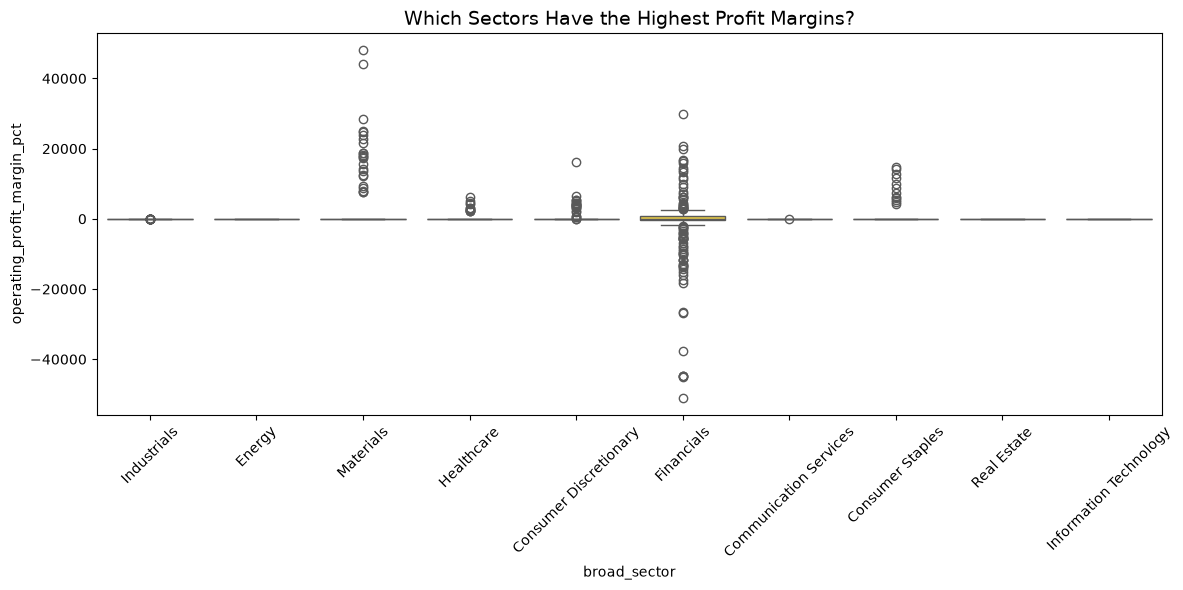

In [13]:
# ==============================================================================
# MILESTONE: Week 2, Day 2 - Sector Margin Leaderboard & Boxplot Analysis
# Description: Merges corporate structural profiles with performance records 
#              to isolate operational advantages across broad sectors.
# ==============================================================================

sectors_df = pd.read_excel(os.path.join(DATASETS_DIR, "sectors.xlsx"))

# Combine financial records with their broad sectors (matching puzzle pieces)
combined_df = pd.merge(ratios_df, sectors_df, on="company_id")

print("--- 🏆 SECTOR HIGHLIGHT: Median Operating Profit Margin (OPM%) ---")
sector_margins = combined_df.groupby('broad_sector')['operating_profit_margin_pct'].median().sort_values(ascending=False)
print(sector_margins)

# Draw a Boxplot to compare sectors visually
plt.figure(figsize=(12, 6))
sns.boxplot(data=combined_df, x='broad_sector', y='operating_profit_margin_pct', palette='Set2')
plt.xticks(rotation=45)
plt.title("Which Sectors Have the Highest Profit Margins?", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
Milestone — The Correlation Map (Week 2, Day 3)
Purpose: This computes the mathematical relationship between metrics to show us which values move like synchronized dancers (positive correlation) and which values move like a playground see-saw (negative correlation).

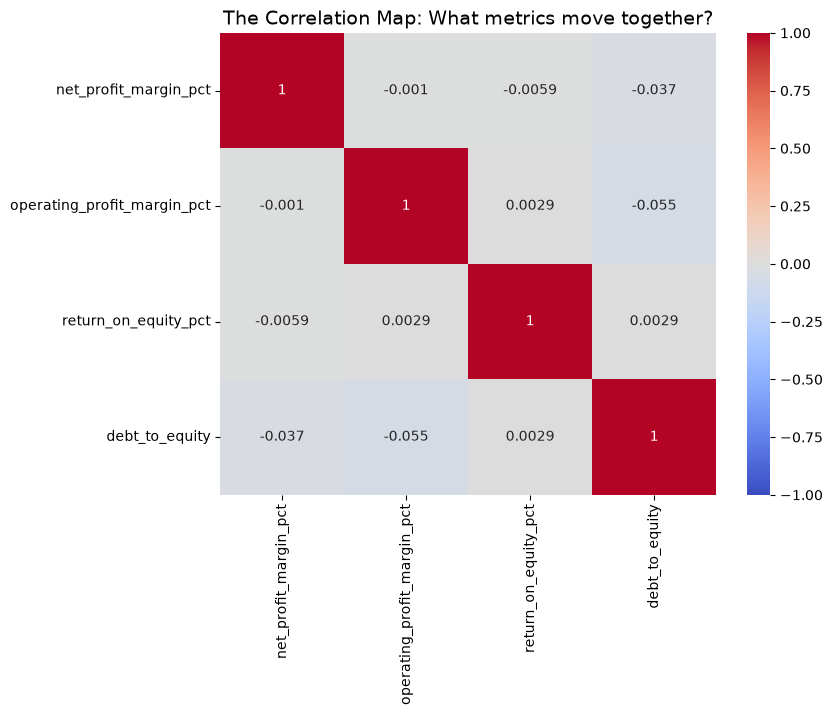

In [14]:
# ==============================================================================
# MILESTONE: Week 2, Day 3 - Financial Feature Correlation Matrix
# Description: Calculates the Pearson correlation coefficients across primary 
#              ratios to isolate statistically interconnected movements.
# ==============================================================================

# Select the numeric columns we want to test
numeric_cols = ['net_profit_margin_pct', 'operating_profit_margin_pct', 'return_on_equity_pct', 'debt_to_equity']
correlation_matrix = ratios_df[numeric_cols].corr()

# Draw the correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("The Correlation Map: What metrics move together?", fontsize=14)
plt.show()